In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('EasyVisa.csv')
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [3]:
df.shape

(25480, 12)

In [4]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [6]:
num_cols = [col for col in df.columns if df[col].dtype != 'O']
cat_cols = [col for col in df.columns if df[col].dtype == 'O']

num_cols, cat_cols

(['no_of_employees', 'yr_of_estab', 'prevailing_wage'],
 ['case_id',
  'continent',
  'education_of_employee',
  'has_job_experience',
  'requires_job_training',
  'region_of_employment',
  'unit_of_wage',
  'full_time_position',
  'case_status'])

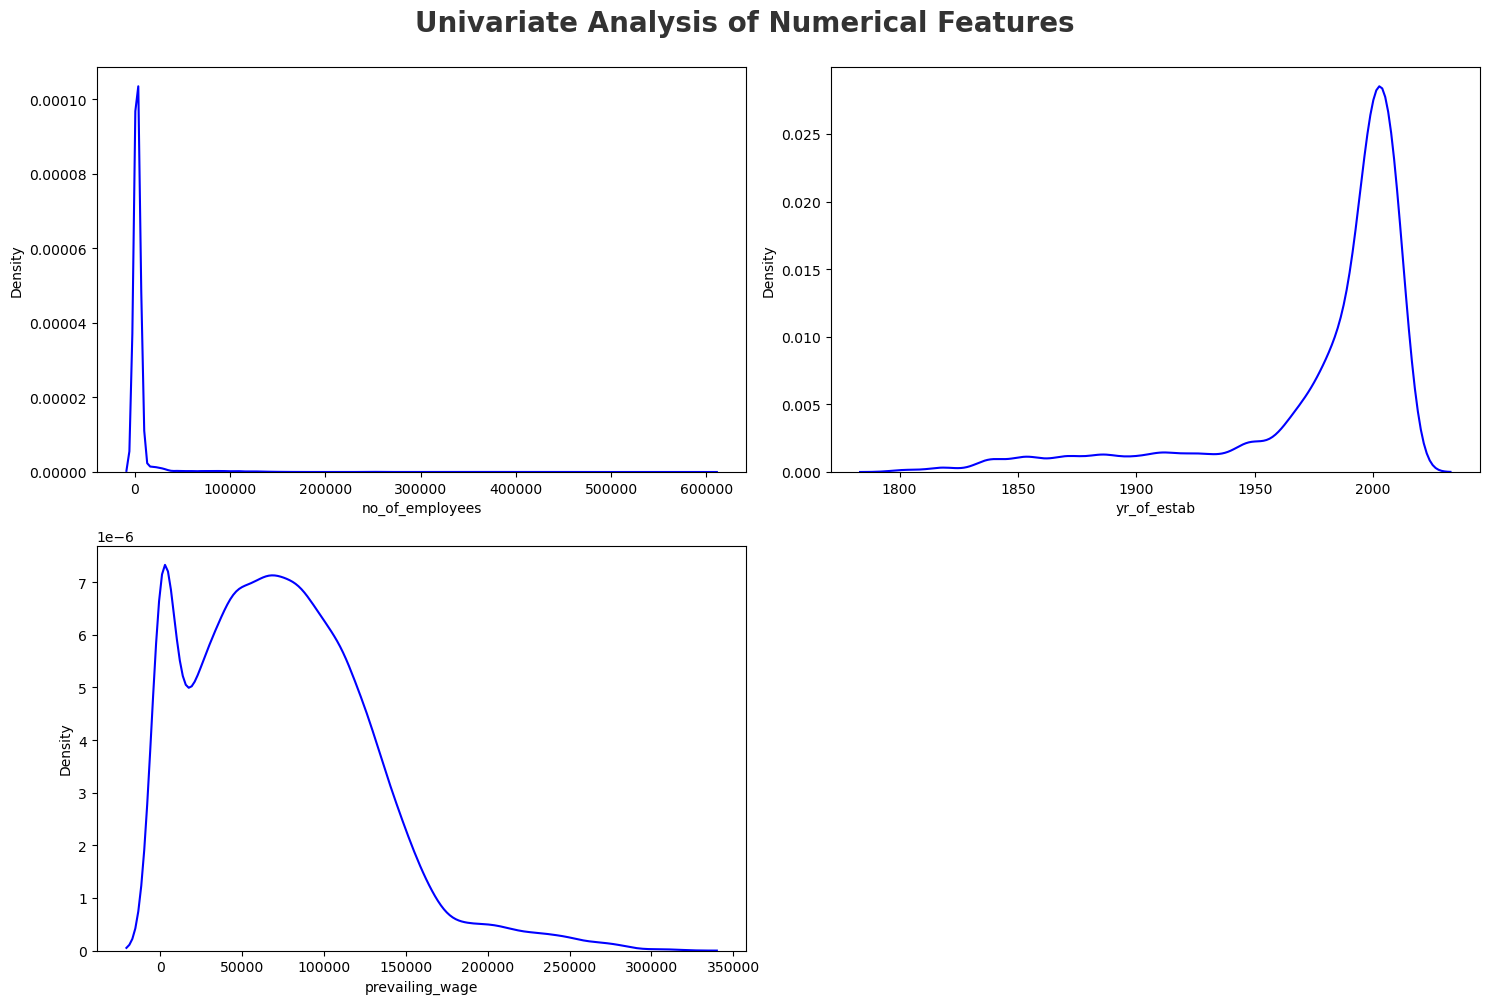

In [7]:
# Univariate anaysis

plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(num_cols)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[num_cols[i]], color='blue')
    plt.xlabel(num_cols[i])
    plt.tight_layout()

In [8]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


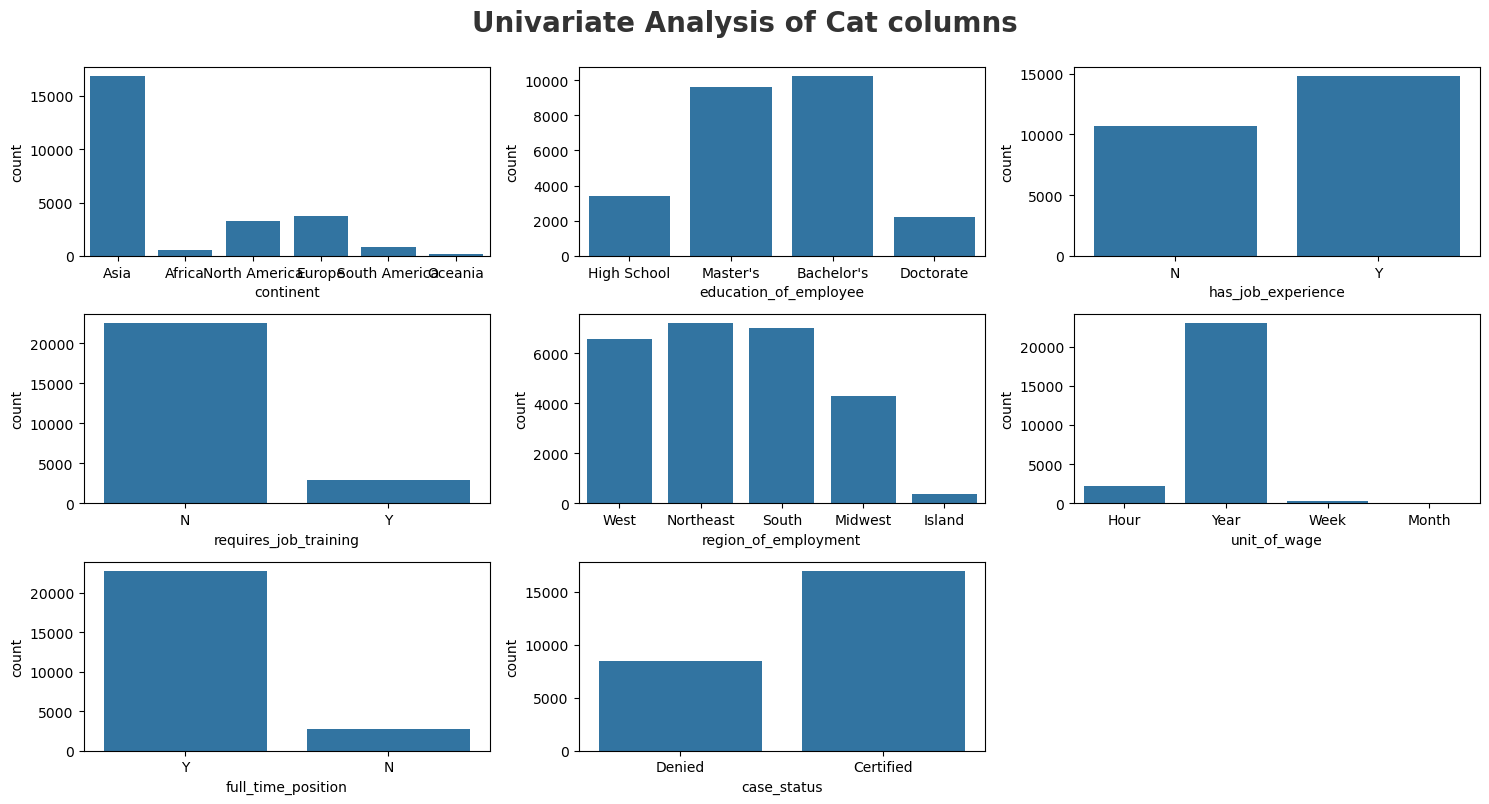

In [9]:
# categorical columns

cat_cols.remove('case_id')
plt.figure(figsize=(15, 8))
plt.suptitle("Univariate Analysis of Cat columns", fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(cat_cols)):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[cat_cols[i]])
    plt.xlabel(cat_cols[i])
    plt.tight_layout()

In [10]:
# multivariate analysis is the analysis of more than one variable

discrete_features = [col for col in df.columns if df[col].nunique() <= 25]
continuous_features = [col for col in df.columns if df[col].nunique() > 25]

In [11]:
print(f"Discrete feature Total: {len(discrete_features)}")
print(f"Continuous Features Total: {len(continuous_features)}")

Discrete feature Total: 8
Continuous Features Total: 4


In [12]:
from scipy.stats import chi2_contingency

chi2_test = []

for feature in cat_cols:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append("Failed to reject Null Hypothesis")

result = pd.DataFrame(data=[cat_cols, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result

,Column,Hypothesis Result
0,continent,Reject Null Hypothesis
1,education_of_employee,Reject Null Hypothesis
2,has_job_experience,Reject Null Hypothesis
3,requires_job_training,Failed to reject Null Hypothesis
4,region_of_employment,Reject Null Hypothesis
5,unit_of_wage,Reject Null Hypothesis
6,full_time_position,Reject Null Hypothesis
7,case_status,Reject Null Hypothesis


In [13]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

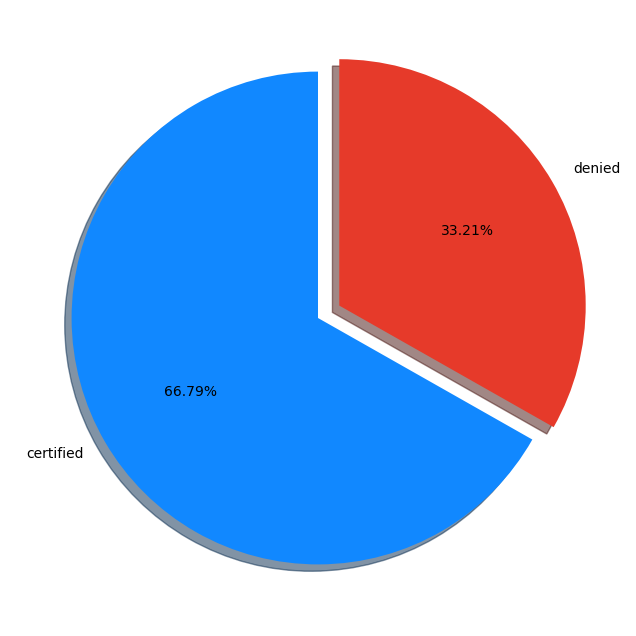

In [14]:
# visualize the target variable

percentage = df['case_status'].value_counts(normalize=True)
labels = ['certified', 'denied']

fig, ax = plt.subplots(figsize=(15, 8))
explode = (0, 0.1)
colors = ['#1188ff', '#e63a2a']
ax.pie(percentage, labels=labels, startangle=90, autopct='%1.2f%%', explode=explode, shadow=True, colors=colors)
plt.show()

In [21]:
df['case_map'] = df.case_status.map({'Denied':0, 'Certified':1})
df['case_map']

0        0
1        1
2        0
3        0
4        1
        ..
25475    1
25476    1
25477    1
25478    1
25479    1
Name: case_map, Length: 25480, dtype: int64

<Axes: xlabel='continent'>

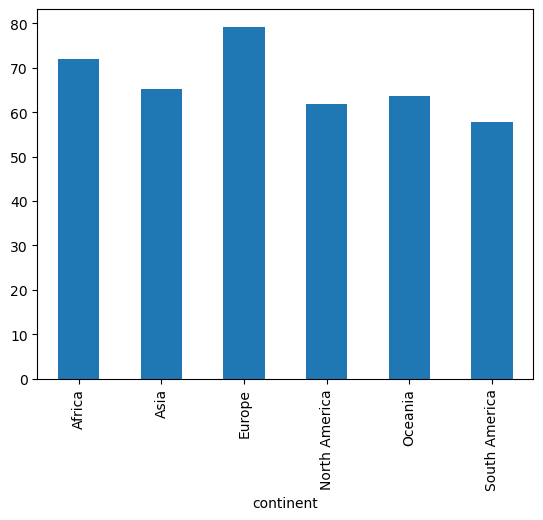

In [49]:
((df.groupby('continent')['case_map'].mean())*100).plot(kind='bar')

In [33]:
# does applicant continent impact case outcome?

round(df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100)

proportion
continent     case_status            
Africa        Certified          72.0
              Denied             28.0
Asia          Certified          65.0
              Denied             35.0
Europe        Certified          79.0
              Denied             21.0
North America Certified          62.0
              Denied             38.0
Oceania       Certified          64.0
              Denied             36.0
South America Certified          58.0
              Denied             42.0

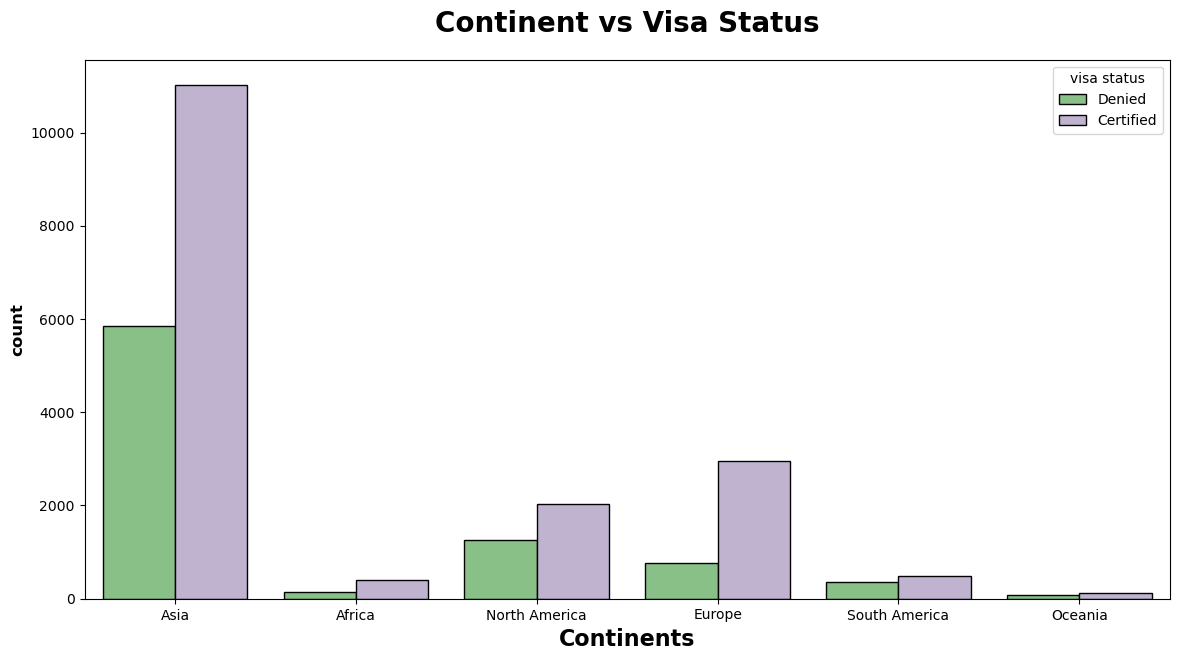

In [34]:
plt.subplots(figsize=(14, 7))
sns.countplot(x='continent', hue='case_status', data=df, ec='black', palette='Accent')
plt.title("Continent vs Visa Status", weight='bold', fontsize=20, pad=20)
plt.ylabel("count", weight='bold', fontsize=12)
plt.xlabel("Continents", weight='bold', fontsize=16)
plt.legend(title='visa status', fancybox=True)
plt.show()

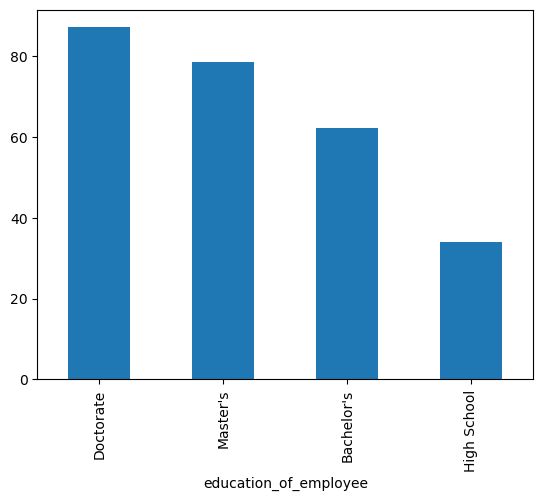

In [53]:
# education level vs visa status

(df.groupby('education_of_employee')['case_map'].mean().sort_values(ascending=False)*100).plot(kind='bar')
plt.show()

In [55]:
df.groupby('has_job_experience')['case_map'].mean().sort_values(ascending=False)*100

has_job_experience
Y    74.476422
N    56.134108
Name: case_map, dtype: float64

In [56]:

df.groupby('requires_job_training')['case_map'].mean().sort_values(ascending=False)*100


requires_job_training
Y    67.884941
N    66.645949
Name: case_map, dtype: float64

In [57]:
# wages and it's impact on visa status

df.groupby('unit_of_wage')['case_map'].mean().sort_values(ascending=False)*100


unit_of_wage
Year     69.885027
Week     62.132353
Month    61.797753
Hour     34.631433
Name: case_map, dtype: float64